# QTPM Growth Heatmaps

This notebook reads precomputed CSV outputs from `scripts/company_ce/build_qtpm.py`, plots the QTPM heatmaps for `at`, `revt`, `emp`, and `dltt`, and saves the combined figure to `fig/company_ce/qtpm/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="white", font_scale=1.0)

cwd = Path.cwd().resolve()
repo_root = next(path for path in [cwd, *cwd.parents] if (path / "AGENTS.md").exists() and (path / "data" / "inf_compustat_anual_US_filter_feas.csv").exists())
csv_dir = repo_root / "results" / "company_ce" / "csv" / "qtpm"
figure_dir = repo_root / "fig" / "company_ce" / "qtpm"
figure_dir.mkdir(parents=True, exist_ok=True)

transitions = pd.read_csv(csv_dir / "qtpm_transitions.csv")
summary = pd.read_csv(csv_dir / "qtpm_summary.csv")
summary

,variable,n_raw_rows,n_positive_rows,n_growth_rows,n_growth_pairs,n_firms_with_pairs,growth_t_mean,growth_t_std,growth_t1_mean,growth_t1_std
0,at,500827,499741,461955,425164,34022,0.133380,0.567078,0.092689,0.514892
1,revt,465630,455920,418222,382975,30566,0.120603,0.520295,0.085939,0.501492
2,emp,399009,394819,356092,321776,27661,0.050229,0.392591,0.027241,0.392404
3,dltt,474358,389937,345426,307166,28148,0.118565,0.958685,0.066743,0.967324


In [4]:
transitions.head()

,from_bin,to_bin,probability,count,row_total,variable
0,1,1,0.333537,14181,42517,at
1,1,2,0.165275,7027,42517,at
2,1,3,0.081168,3451,42517,at
3,1,4,0.052802,2245,42517,at
4,1,5,0.037773,1606,42517,at


PosixPath('/Users/taoruyi/Downloads/project/company/EISyn/fig/company_ce/qtpm/qtpm_growth_heatmaps.png')

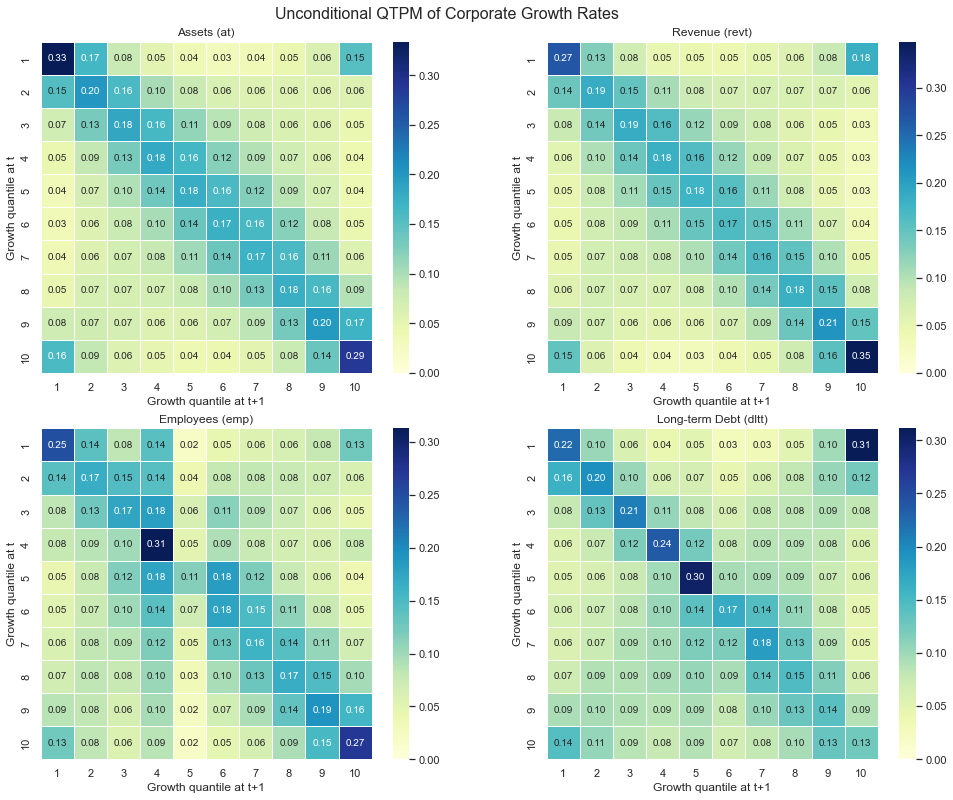

In [2]:
variable_labels = {
    "at": "Assets (at)",
    "revt": "Revenue (revt)",
    "emp": "Employees (emp)",
    "dltt": "Long-term Debt (dltt)",
}

variables = ["at", "revt", "emp", "dltt"]
fig, axes = plt.subplots(2, 2, figsize=(14, 11), constrained_layout=True)

for ax, variable in zip(axes.flat, variables):
    matrix = (
        transitions.loc[transitions["variable"] == variable]
        .pivot(index="from_bin", columns="to_bin", values="probability")
        .sort_index()
        .sort_index(axis=1)
    )
    sns.heatmap(
        matrix,
        ax=ax,
        cmap="YlGnBu",
        vmin=0,
        vmax=max(0.2, float(matrix.to_numpy().max())),
        cbar=True,
        square=True,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        linecolor="white",
    )
    ax.set_title(variable_labels[variable])
    ax.set_xlabel("Growth quantile at t+1")
    ax.set_ylabel("Growth quantile at t")

fig.suptitle("Unconditional QTPM of Corporate Growth Rates", fontsize=16)
figure_path = figure_dir / "qtpm_growth_heatmaps.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
figure_path

In [3]:
plt.show()